In [2]:
import sys
from pathlib import Path
import yaml
import matplotlib.pyplot as plt
# 1. Get the project root (Path.cwd() gets the 'notebooks' folder, .parent goes up one level)
PROJECT_ROOT = Path.cwd().parent

# 2. Add the project root to sys.path so Python can find the 'src' folder
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 3. NOW you can safely import from src
from src.data import loader

# 4. Load your config
with open(PROJECT_ROOT / "configs" / "config.yaml") as f:
    config = yaml.safe_load(f)

# Convert relative paths to absolute paths
for key, value in config["paths"].items():
    config["paths"][key] = PROJECT_ROOT / value

In [3]:
X_train, y_train, subjects_train, X_test, y_test, subjects_test = loader.load_dataset(config)

In [4]:
X_train.shape

(7352, 561)

In [5]:
X_test.shape

(2947, 561)

In [6]:
y_train.value_counts().sort_index()

0
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64

In [7]:
subjects_train.nunique()

21

In [8]:
subjects_test.nunique()

9

In [9]:
X_train.isna().sum().sum()

np.int64(0)

In [10]:
X_test.isna().sum().sum()

np.int64(0)

In [27]:
X_train.columns.duplicated().sum()

np.int64(84)

In [28]:
duplicate_names = X_train.columns[X_train.columns.duplicated()]

print(len(duplicate_names))
print(duplicate_names.tolist()[:10])  # first 10 duplicate names

84
['fBodyAcc-bandsEnergy()-1,8', 'fBodyAcc-bandsEnergy()-9,16', 'fBodyAcc-bandsEnergy()-17,24', 'fBodyAcc-bandsEnergy()-25,32', 'fBodyAcc-bandsEnergy()-33,40', 'fBodyAcc-bandsEnergy()-41,48', 'fBodyAcc-bandsEnergy()-49,56', 'fBodyAcc-bandsEnergy()-57,64', 'fBodyAcc-bandsEnergy()-1,16', 'fBodyAcc-bandsEnergy()-17,32']


In [29]:
name = duplicate_names[0]
cols = X_train.loc[:, X_train.columns == name]

print(cols.shape)

(7352, 3)


In [30]:
cols.iloc[:, 0].equals(cols.iloc[:, 1])

False

In [31]:
duplicate_names = X_train.columns[X_train.columns.duplicated()].unique()

for name in duplicate_names:
    cols = X_train.loc[:, X_train.columns == name]

    if cols.shape[1] == 2:
        print(name, cols.iloc[:, 0].equals(cols.iloc[:, 1]))

In [32]:
duplicate_names = X_train.columns[X_train.columns.duplicated()].unique()

same = 0
different = 0

for name in duplicate_names:
    cols = X_train.loc[:, X_train.columns == name]

    if cols.iloc[:, 0].equals(cols.iloc[:, 1]):
        same += 1
    else:
        different += 1

print("Same:", same)
print("Different:", different)

Same: 0
Different: 42


<BarContainer object of 7352 artists>

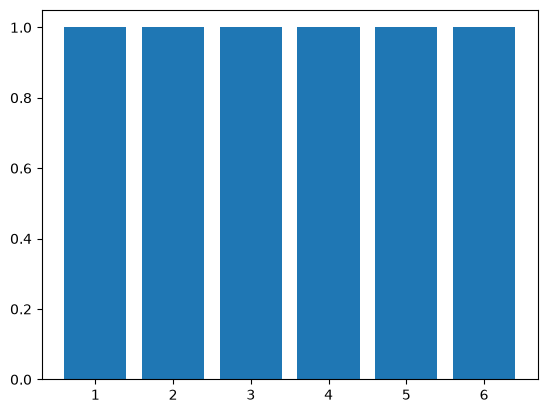

In [32]:
plt.bar(y_train,1)

<BarContainer object of 2947 artists>

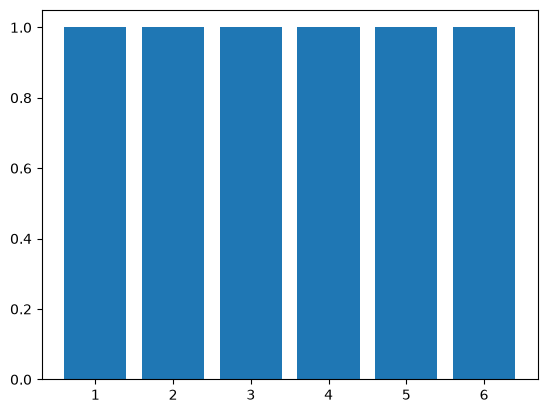

In [33]:
plt.bar(y_test,1)

In [19]:
subjects_train.value_counts().sort_index()

0
1     347
3     341
5     302
6     325
7     308
8     281
11    316
14    323
15    328
16    366
17    368
19    360
21    408
22    321
23    372
25    409
26    392
27    376
28    382
29    344
30    383
Name: count, dtype: int64

In [34]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
tBodyAcc-mean()-X,7352.0,0.274488,0.070261,-1.000000,0.262975,0.277193,0.288461,1.000000
tBodyAcc-mean()-Y,7352.0,-0.017695,0.040811,-1.000000,-0.024863,-0.017219,-0.010783,1.000000
tBodyAcc-mean()-Z,7352.0,-0.109141,0.056635,-1.000000,-0.120993,-0.108676,-0.097794,1.000000
tBodyAcc-std()-X,7352.0,-0.605438,0.448734,-1.000000,-0.992754,-0.946196,-0.242813,1.000000
tBodyAcc-std()-Y,7352.0,-0.510938,0.502645,-0.999873,-0.978129,-0.851897,-0.034231,0.916238
...,...,...,...,...,...,...,...,...
"angle(tBodyGyroMean,gravityMean)",7352.0,0.008726,0.608303,-1.000000,-0.482273,0.008735,0.506187,0.998702
"angle(tBodyGyroJerkMean,gravityMean)",7352.0,-0.005981,0.477975,-1.000000,-0.376341,-0.000368,0.359368,0.996078
"angle(X,gravityMean)",7352.0,-0.489547,0.511807,-1.000000,-0.812065,-0.709417,-0.509079,1.000000
"angle(Y,gravityMean)",7352.0,0.058593,0.297480,-1.000000,-0.017885,0.182071,0.248353,0.478157


<Axes: xlabel='0'>

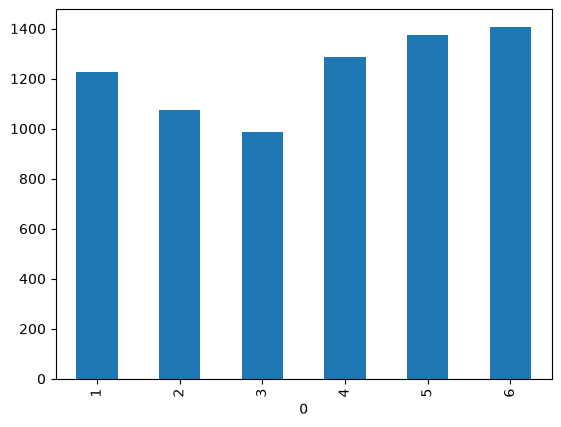

In [35]:
y_train.value_counts().sort_index().plot.bar()

In [37]:
corr = X_train.corr()

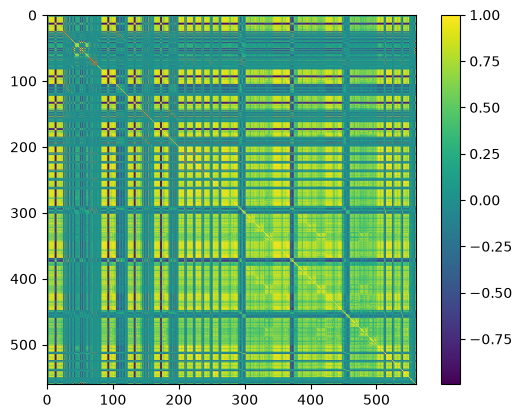

In [38]:
plt.imshow(corr)
plt.colorbar()

In [39]:
corr.abs().stack().sort_values(ascending=False)

angle(Z,gravityMean)                  angle(Z,gravityMean)                    1.000000
angle(Y,gravityMean)                  angle(Y,gravityMean)                    1.000000
angle(X,gravityMean)                  angle(X,gravityMean)                    1.000000
angle(tBodyGyroJerkMean,gravityMean)  angle(tBodyGyroJerkMean,gravityMean)    1.000000
angle(tBodyGyroMean,gravityMean)      angle(tBodyGyroMean,gravityMean)        1.000000
                                                                                ...   
tBodyGyroJerk-mean()-Y                tBodyAccJerk-arCoeff()-Z,3              0.000004
fBodyGyro-kurtosis()-X                fBodyGyro-bandsEnergy()-9,16            0.000003
fBodyGyro-bandsEnergy()-9,16          fBodyGyro-kurtosis()-X                  0.000003
tBodyGyro-min()-Z                     tBodyGyroMag-arCoeff()4                 0.000002
tBodyGyroMag-arCoeff()4               tBodyGyro-min()-Z                       0.000002
Length: 314721, dtype: float64

<Axes: >

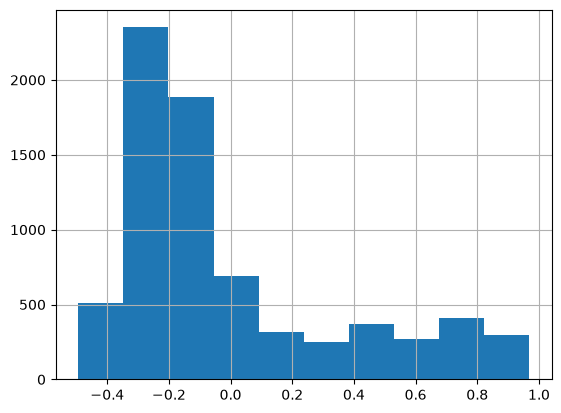

In [40]:
X_train.iloc[:,50].hist()

<Axes: xlabel='0'>

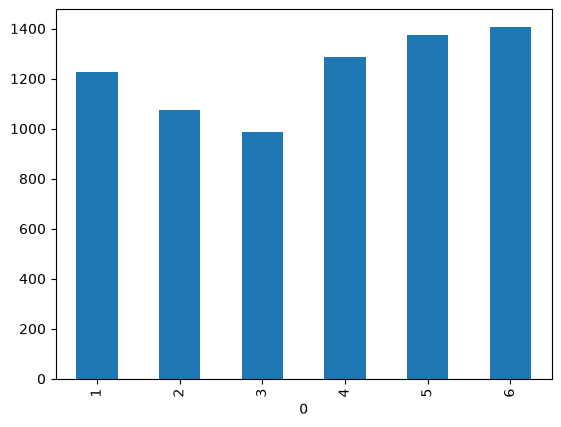

In [41]:
y_train.value_counts().sort_index().plot.bar()

Dataset contains 7352 training and 2947 testing samples.

No missing values.

561 engineered IMU features.

84 duplicate feature names requiring preprocessing.

Classes approximately balanced.

Subject-based split already provided.

This becomes documentation for yourself.
